<a href="https://colab.research.google.com/github/AhmedGDeeb/DataTalksClub/blob/main/machine-learning-zoomcamp/cohorts/2026/homework/02-regression/homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up the environment

In [95]:
!pip install pandas numpy matplotlib seaborn

In [96]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# utils

In [97]:
# Prepare and split the dataset
def split_dataset(df, seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


In [98]:
# linear regression
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [99]:
# linear regression with regularization
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [100]:
# Root Mean Squared Error (RMSE)
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

# Get data

In [101]:
raw_df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [102]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  object 
 2   fuel_type            10000 non-null  object 
 3   drivetrain           10000 non-null  object 
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB


### Preparing the dataset

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

In [103]:
df = raw_df[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]]

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


## EDA
* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

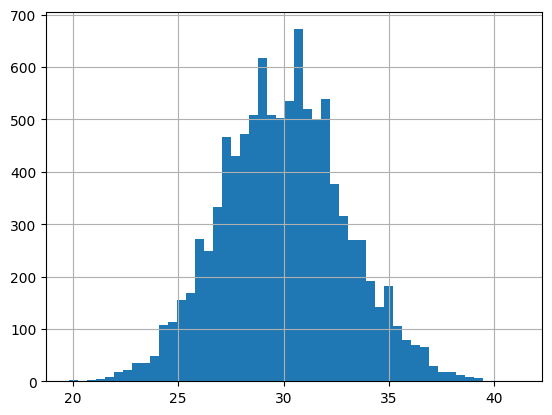

In [105]:
df['fuel_efficiency_mpg'].hist(bins=50)
plt.show()

`fuel_efficiency_mpg` is almost normally dsitributed, it **does not** have a `long tail` distribution.

# Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`

In [106]:
df.columns[df.isnull().any()].tolist()

['horsepower']

## Answer:

`'horsepower'`

# Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354

In [107]:
df['horsepower'].quantile(0.5)

np.float64(254.0)

In [108]:
# simpler way
df['horsepower'].median()

254.0

# Answer

254

# Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

## Zero-filled model

In [109]:
# split data
df_0_train, df_0_val, df_0_test = split_dataset(df)

In [110]:
# fill data
df_0_train = df_0_train.fillna(0)
df_0_val = df_0_val.fillna(0)
df_0_test = df_0_test.fillna(0)

df_0_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 6252 to 3252
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  6000 non-null   int64  
 1   horsepower           6000 non-null   float64
 2   vehicle_weight       6000 non-null   int64  
 3   model_year           6000 non-null   int64  
 4   fuel_efficiency_mpg  6000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 281.2 KB


In [111]:
# train, validate
X_0_train = df_0_train.drop(columns=['fuel_efficiency_mpg'])
y_0_train = df_0_train['fuel_efficiency_mpg']
X_0_val = df_0_val.drop(columns=['fuel_efficiency_mpg'])
y_0_val = df_0_val['fuel_efficiency_mpg']

# get trained weights
lr_0_w0, lr_0_w = train_linear_regression(X_0_train, y_0_train)

# predict
y_0_train_pred = lr_0_w0 + X_0_train.dot(lr_0_w)
y_0_val_pred = lr_0_w0 + X_0_val.dot(lr_0_w)

Training RMSE: 2.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

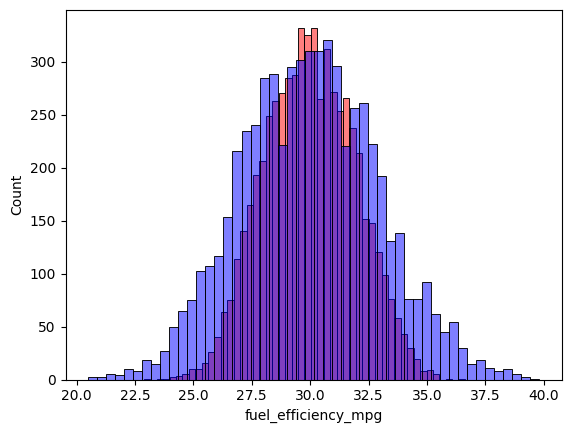

In [112]:
# take a look on the training
train_0_rmse = rmse(y_0_train_pred, y_0_train)
print("Training RMSE: {}".format(round(train_0_rmse, 3)))
sns.histplot(y_0_train_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_0_train, color='blue', alpha=0.5, bins=50)

Validation RMSE: 2.205


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

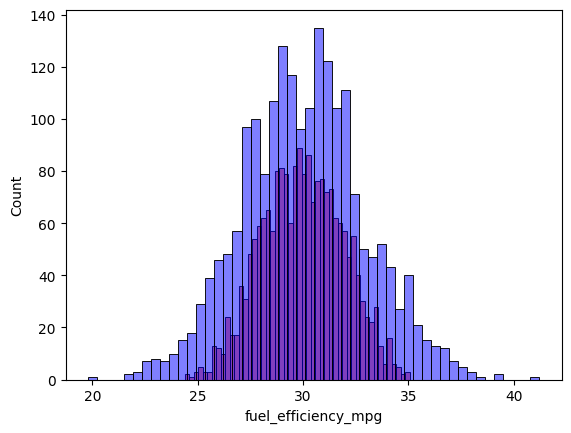

In [113]:
# take a look on the validation
val_0_rmse = rmse(y_0_val_pred, y_0_val)
print("Validation RMSE: {}".format(round(val_0_rmse, 3)))
sns.histplot(y_0_val_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_0_val, color='blue', alpha=0.5, bins=50)

## mean-filled model

In [114]:
# split data
df_mean_train, df_mean_val, df_mean_test = split_dataset(df)

In [115]:
# fill data with train mean
df_mean_train = df_mean_train.fillna(df_mean_train.mean(numeric_only=True))
df_mean_val = df_mean_val.fillna(df_mean_train.mean(numeric_only=True))
df_mean_test = df_mean_test.fillna(df_mean_train.mean(numeric_only=True))

# or to be specific
df_mean_train.fillna({'horsepower':df_mean_train['horsepower'].mean()}, inplace=True)
df_mean_val.fillna({'horsepower':df_mean_train['horsepower'].mean()}, inplace=True)
df_mean_test.fillna({'horsepower':df_mean_train['horsepower'].mean()}, inplace=True)

df_mean_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 6252 to 3252
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  6000 non-null   int64  
 1   horsepower           6000 non-null   float64
 2   vehicle_weight       6000 non-null   int64  
 3   model_year           6000 non-null   int64  
 4   fuel_efficiency_mpg  6000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 281.2 KB


In [116]:
# train, validate
# train, validate
X_mean_train = df_mean_train.drop(columns=['fuel_efficiency_mpg'])
y_mean_train = df_mean_train['fuel_efficiency_mpg']
X_mean_val = df_mean_val.drop(columns=['fuel_efficiency_mpg'])
y_mean_val = df_mean_val['fuel_efficiency_mpg']

# get trained weights
lr_mean_w0, lr_mean_w = train_linear_regression(X_mean_train, y_mean_train)

# predict
y_mean_train_pred = lr_mean_w0 + X_mean_train.dot(lr_mean_w)
y_mean_val_pred = lr_mean_w0 + X_mean_val.dot(lr_mean_w)

Training RMSE: 2.198


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

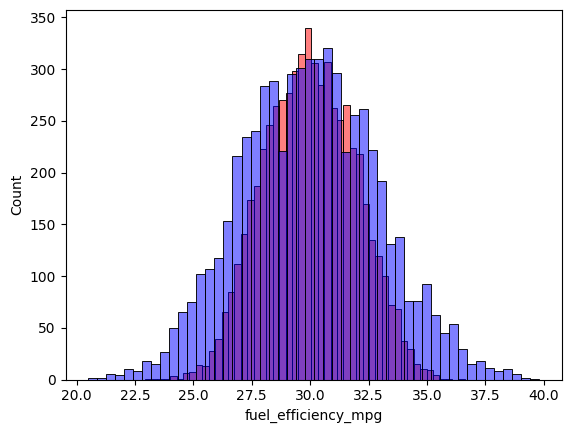

In [117]:
# take a look on the training
train_mean_rmse = rmse(y_mean_train_pred, y_mean_train)
print("Training RMSE: {}".format(round(train_mean_rmse, 3)))
sns.histplot(y_mean_train_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_mean_train, color='blue', alpha=0.5, bins=50)

Validation RMSE: 2.202


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

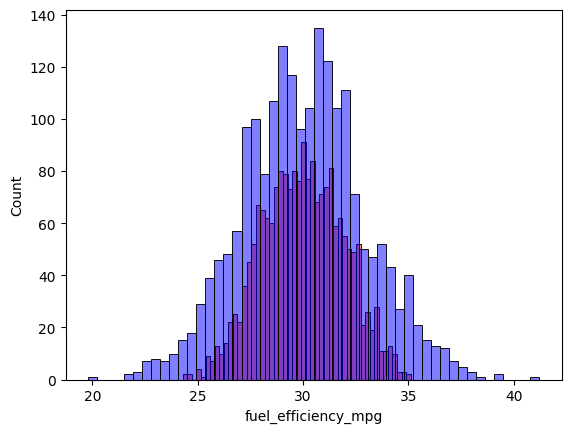

In [118]:
# take a look on the validation
val_mean_rmse = rmse(y_mean_val_pred, y_mean_val)
print("Validation RMSE: {}".format(round(val_mean_rmse, 3)))
sns.histplot(y_mean_val_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_mean_val, color='blue', alpha=0.5, bins=50)

# Answer

In [119]:
print("RMSE:\n With 0: {} vs With mean: {}".format(round(val_0_rmse, 3), round(val_mean_rmse, 3)))
print("-"*20)
if (val_0_rmse < val_mean_rmse):
    print("With 0")
elif (val_0_rmse > val_mean_rmse):
    print("With mean")
else:
    print("Both are equally good")

RMSE:
 With 0: 2.205 vs With mean: 2.202
--------------------
With mean


# Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0.
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


In [126]:
df_0 = df.fillna(0)
df_train, df_val, df_test = split_dataset(df_0)
X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
y_train = df_train['fuel_efficiency_mpg']
X_val = df_val.drop(columns=['fuel_efficiency_mpg'])
y_val = df_val['fuel_efficiency_mpg']

rs = [0, 0.01, 0.1, 1, 5, 10, 100]
rmses = {}

for r in rs:
    # get trained weights
    lr_w0, lr_w = train_linear_regression_reg(X_train, y_train, r)

    # predict
    y_val_pred = lr_w0 + X_val.dot(lr_w)

    rmses[r] = round(rmse(y_val_pred, y_val), 4)

print("RMSEs:")
for k, v in rmses.items():
    print("\tr = {}, RMSE = {}".format(k, v))


RMSEs:
	r = 0, RMSE = 2.2053
	r = 0.01, RMSE = 2.2058
	r = 0.1, RMSE = 2.2241
	r = 1, RMSE = 2.3492
	r = 5, RMSE = 2.4094
	r = 10, RMSE = 2.4195
	r = 100, RMSE = 2.4292


# Answer

In [129]:
# minimize values and get key
best_r = min(rmses, key=rmses.get)
print(best_r)

0


# Question 5

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different.
> If standard deviation of scores is low, then our model is *stable*.


In [122]:
rmses = []

for seed in range(10):
    df_0 = df.fillna(0)
    df_train, df_val, df_test = split_dataset(df=df_0, seed=seed)
    X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
    y_train = df_train['fuel_efficiency_mpg']
    X_val = df_val.drop(columns=['fuel_efficiency_mpg'])
    y_val = df_val['fuel_efficiency_mpg']

    # get trained weights
    lr_w0, lr_w = train_linear_regression(X_train, y_train)

    # predict
    y_val_pred = lr_w0 + X_val.dot(lr_w)

    # RMSE
    val_rmse = round(rmse(y_val_pred, y_val), 3)
    rmses.append(val_rmse)

    # show result
    print("Seed = {}, RMSE = {}".format(seed, val_rmse))

Seed = 0, RMSE = 2.239
Seed = 1, RMSE = 2.202
Seed = 2, RMSE = 2.163
Seed = 3, RMSE = 2.204
Seed = 4, RMSE = 2.202
Seed = 5, RMSE = 2.246
Seed = 6, RMSE = 2.27
Seed = 7, RMSE = 2.191
Seed = 8, RMSE = 2.217
Seed = 9, RMSE = 2.207


# Answer

In [123]:
round(np.std(rmses), 3)

np.float64(0.029)

# Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`.
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10

In [124]:
df_0 = df.fillna(0)
df_train, df_val, df_test = split_dataset(df=df_0, seed=9)
X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
y_train = df_train['fuel_efficiency_mpg']
X_val = df_val.drop(columns=['fuel_efficiency_mpg'])
y_val = df_val['fuel_efficiency_mpg']
X_test = df_test.drop(columns=['fuel_efficiency_mpg'])
y_test = df_test['fuel_efficiency_mpg']

# combine train and val datasets
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# get trained weights
lr_w0, lr_w = train_linear_regression(X_train_val, y_train_val)

# predict
y_test_pred = lr_w0 + X_test.dot(lr_w)

# RMSE
test_rmse = round(rmse(y_test_pred, y_test), 3)

# Answer

In [130]:
print(test_rmse)

2.236


# Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.
